### Мы визуализируем данные и возможно сможем узнать о них что-то новое

In [1]:
import pandas as pd


train_sparse = pd.read_csv('../../data/Cleared_data/train_sparse.csv', parse_dates=['date', 'created'])

In [2]:
train_sparse

,station_id,date,daily_sales_count,created,partner_name,employee_name,cities
0,277,2023-07-04,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
1,277,2023-07-05,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
2,277,2023-07-06,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
3,277,2023-07-07,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
4,277,2023-07-08,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
...,...,...,...,...,...,...,...
1422218,3952,2026-07-29,0.0,2026-07-24,Beeline,Никита,Самара
1422219,3952,2026-07-30,0.0,2026-07-24,Beeline,Никита,Самара
1422220,3952,2026-07-31,0.0,2026-07-24,Beeline,Никита,Самара
1422221,3953,2026-07-30,1.0,2026-07-30,Inventive Group,Екатерина,Санкт-Петербург


In [3]:
train_sparse['last_sale'] = train_sparse.groupby('station_id')['date'].transform('max')


In [4]:
train_sparse.info()

<class 'pandas.DataFrame'>
RangeIndex: 1422223 entries, 0 to 1422222
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   station_id         1422223 non-null  int64         
 1   date               1422223 non-null  datetime64[us]
 2   daily_sales_count  1422223 non-null  float64       
 3   created            1422223 non-null  datetime64[us]
 4   partner_name       1422223 non-null  str           
 5   employee_name      1422223 non-null  str           
 6   cities             1422223 non-null  str           
 7   last_sale          1422223 non-null  datetime64[us]
dtypes: datetime64[us](3), float64(1), int64(1), str(3)
memory usage: 86.8 MB


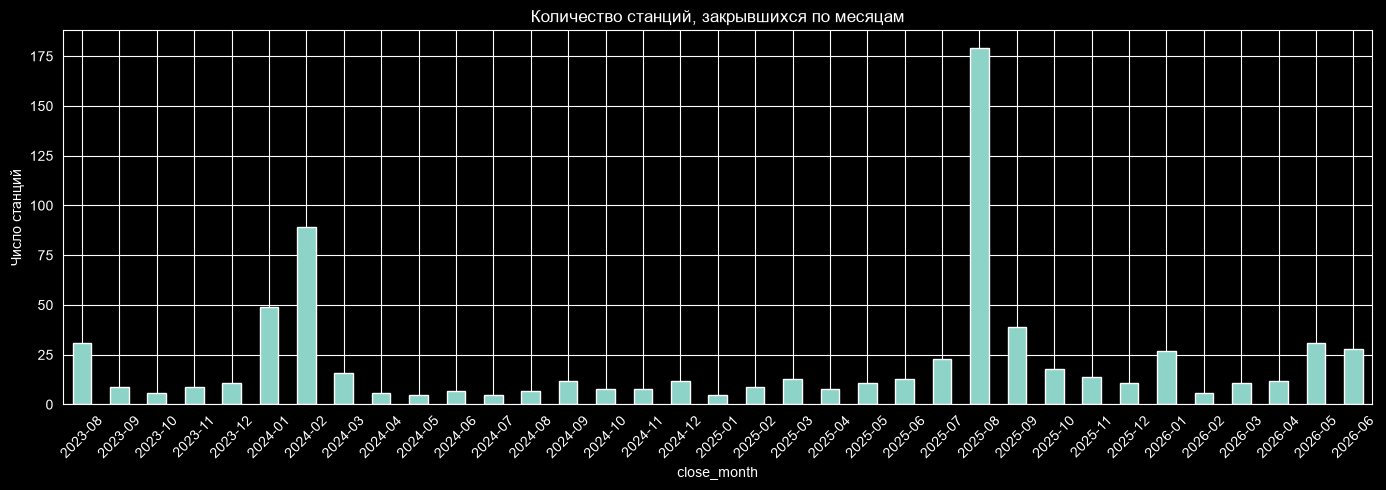

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

closures = train_sparse[['station_id', 'last_sale']].drop_duplicates()
closures = closures[closures['last_sale'] <= pd.to_datetime('2026-06-30')]

# группируем по месяцу
closures['close_month'] = closures['last_sale'].dt.to_period('M')
monthly_closures = closures.groupby('close_month').size()

monthly_closures.plot(kind='bar', figsize=(14,5), title='Количество станций, закрывшихся по месяцам')
plt.ylabel('Число станций')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Как мы видим, станции закрываются регулярно, а значит надо учитывать этот фактор и очищать данные от закрывшихся станций. К счастью у нас в матрице train_sparse данные проставлены так, что после последней продажи для станции у нас не идут нули, а просто нет записей.


### Посмотрим на то, сколько вообще обычно работают станции.

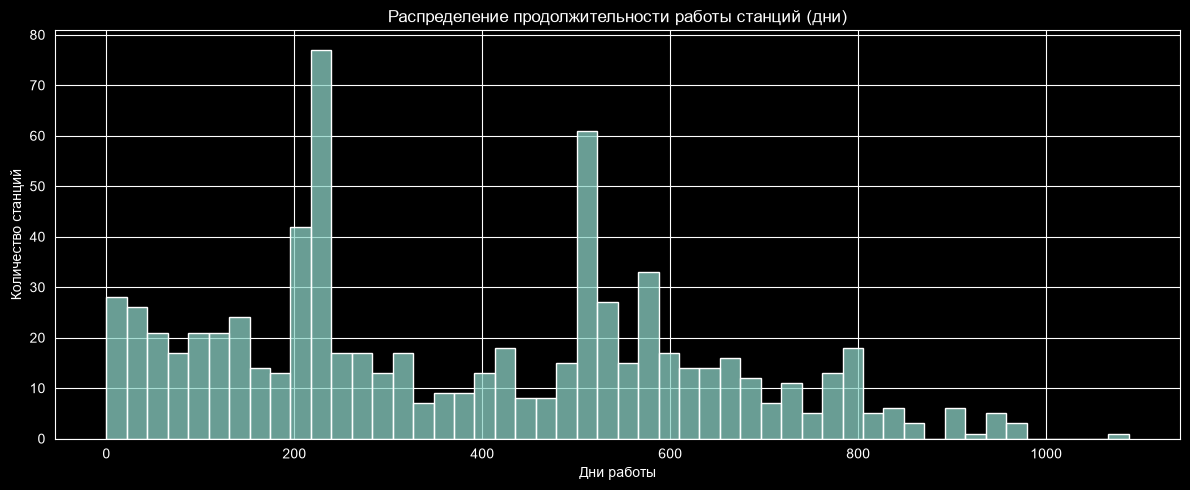

In [6]:
work_duration = train_sparse[['station_id', 'created', 'last_sale']].drop_duplicates()
work_duration = work_duration[work_duration['last_sale'] <= pd.to_datetime('2026-06-30')]

work_duration['duration'] = (work_duration['last_sale'] - work_duration['created'])
work_duration['duration_days'] = work_duration['duration'].dt.days

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.histplot(data=work_duration, x='duration_days', bins=50)
plt.title('Распределение продолжительности работы станций (дни)')
plt.xlabel('Дни работы')
plt.ylabel('Количество станций')
plt.tight_layout()
plt.show()

### Теперь узнаем, сколько станций продолжало работать в каждый из месяцев

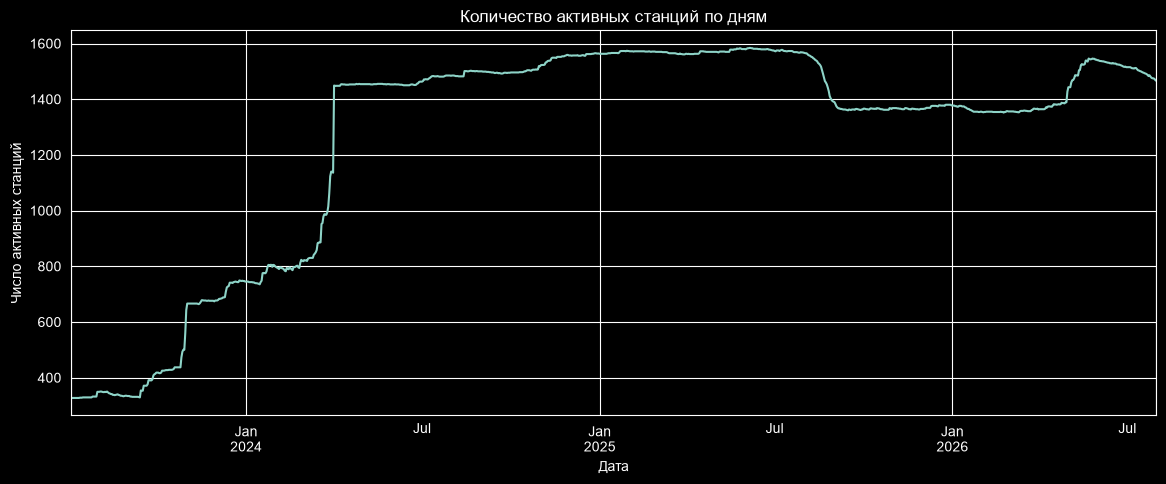

In [7]:
active_per_day = train_sparse.groupby('date')['station_id'].nunique()

active_per_day.plot(figsize=(14,5), title='Количество активных станций по дням')
plt.xlabel('Дата')
plt.ylabel('Число активных станций')
plt.show()

Мы видим, что в целом, начиная с марта 2024 года у нас есть всегда более 1000 рабочих станций, то есть недостатка в данных у нас нет.